In [1]:
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR     = r'C:\Users\rahul\OneDrive\Desktop\Projects\Eye Disease Detection\Eye Disease Detection\Eye-Disease-Detection'
FEATURES_DIR = os.path.join(BASE_DIR, 'features')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(BASE_DIR, 'checkpoints')
CLASSES      = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

In [3]:
train_features = np.load(os.path.join(FEATURES_DIR, 'train_features.npy'))
train_labels   = np.load(os.path.join(FEATURES_DIR, 'train_labels.npy'))
val_features   = np.load(os.path.join(FEATURES_DIR, 'val_features.npy'))
val_labels     = np.load(os.path.join(FEATURES_DIR, 'val_labels.npy'))
test_features  = np.load(os.path.join(FEATURES_DIR, 'test_features.npy'))
test_labels    = np.load(os.path.join(FEATURES_DIR, 'test_labels.npy'))

In [4]:
print(f"Train : {train_features.shape}")
print(f"Val   : {val_features.shape}")
print(f"Test  : {test_features.shape}")

Train : (83484, 2048)
Val   : (32, 2048)
Test  : (968, 2048)


In [5]:
def evaluate_model(model, features, labels, split_name='Test'):
    predictions = model.predict(features)
    probabilities = model.predict_proba(features)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro')

    labels_binarized = label_binarize(labels, classes=[0, 1, 2, 3])
    auc_roc = roc_auc_score(labels_binarized, probabilities,
                            multi_class='ovr', average='macro')

    print(f"\n{split_name} Results")
    print("-" * 40)
    print(f"  Accuracy    : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Macro F1    : {macro_f1:.4f}")
    print(f"  AUC-ROC     : {auc_roc:.4f}")
    print(f"\n  Per-class breakdown:")
    print(classification_report(labels, predictions,
                                target_names=CLASSES, digits=4))

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'auc_roc' : auc_roc,
        'predictions' : predictions,
        'probabilities': probabilities
    }

In [6]:
def plot_confusion_matrix(labels, predictions, title, save_path=None):
    cm = confusion_matrix(labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='gray')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Actual Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
class_weights = {0: 0.5610, 1: 1.8392, 2: 2.4224, 3: 0.7931}

In [8]:
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=class_weights,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_model.fit(train_features, train_labels)

elapsed = time.time() - start_time
print(f"\nRandom Forest training complete")
print(f"Training time: {elapsed/60:.1f} minutes ({elapsed:.0f} seconds)")
print(f"Number of trees: {rf_model.n_estimators}")

joblib.dump(rf_model, os.path.join(MODELS_DIR, 'rf_model.pkl'))
print("Model saved as 'rf_model.pkl'")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   25.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  3.8min finished



Random Forest training complete
Training time: 3.8 minutes (227 seconds)
Number of trees: 300
Model saved as 'rf_model.pkl'


RANDOM FOREST EVALUATION
------------------------------------------------------------

Validation Set:


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished



Validation Results
----------------------------------------
  Accuracy    : 0.9375 (93.75%)
  Macro F1    : 0.9349
  AUC-ROC     : 1.0000

  Per-class breakdown:
              precision    recall  f1-score   support

         CNV     0.8889    1.0000    0.9412         8
         DME     1.0000    0.7500    0.8571         8
      DRUSEN     1.0000    1.0000    1.0000         8
      NORMAL     0.8889    1.0000    0.9412         8

    accuracy                         0.9375        32
   macro avg     0.9444    0.9375    0.9349        32
weighted avg     0.9444    0.9375    0.9349        32


Test Set:


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished



Test Results
----------------------------------------
  Accuracy    : 0.9638 (96.38%)
  Macro F1    : 0.9636
  AUC-ROC     : 0.9997

  Per-class breakdown:
              precision    recall  f1-score   support

         CNV     0.9098    1.0000    0.9528       242
         DME     1.0000    0.8843    0.9386       242
      DRUSEN     1.0000    0.9711    0.9853       242
      NORMAL     0.9565    1.0000    0.9778       242

    accuracy                         0.9638       968
   macro avg     0.9666    0.9638    0.9636       968
weighted avg     0.9666    0.9638    0.9636       968



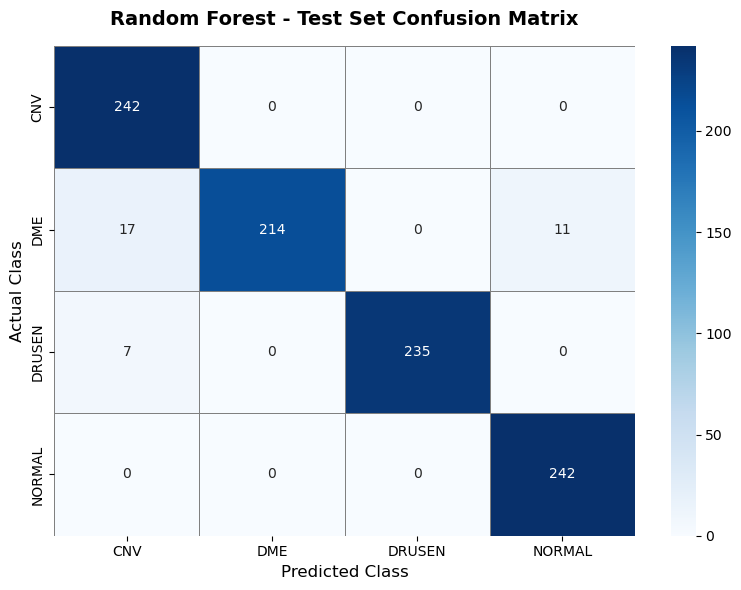

In [9]:
print("RANDOM FOREST EVALUATION")
print("-"*60)

print("\nValidation Set:")
rf_val_results = evaluate_model(rf_model, val_features, val_labels, split_name='Validation')

print("\nTest Set:")
rf_test_results = evaluate_model(rf_model, test_features, test_labels, split_name='Test')

plot_confusion_matrix(
    test_labels,
    rf_test_results['predictions'],
    title='Random Forest - Test Set Confusion Matrix',
    save_path=os.path.join(RESULTS_DIR, 'rf_confusion_matrix.png')
)

Total features: 2048
Features with nonzero importance: 2048
Top 10 features account for: 5.5% of total importance
Top 50 features account for: 16.1% of total importance
Top 100 features account for: 24.0% of total importance


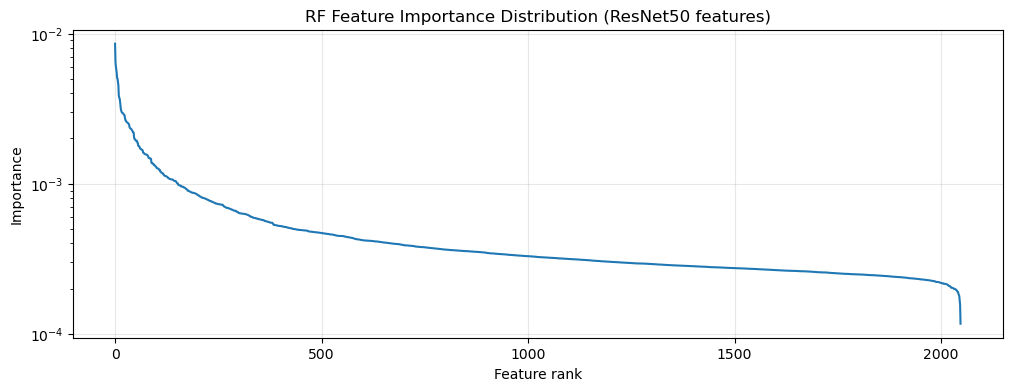

In [10]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

# Summary stats
print(f"Total features: {len(importances)}")
print(f"Features with nonzero importance: {(importances > 0).sum()}")
print(f"Top 10 features account for: {importances[sorted_idx[:10]].sum()*100:.1f}% of total importance")
print(f"Top 50 features account for: {importances[sorted_idx[:50]].sum()*100:.1f}% of total importance")
print(f"Top 100 features account for: {importances[sorted_idx[:100]].sum()*100:.1f}% of total importance")

# Plot
plt.figure(figsize=(12, 4))
plt.plot(np.sort(importances)[::-1])
plt.xlabel('Feature rank')
plt.ylabel('Importance')
plt.title('RF Feature Importance Distribution (ResNet50 features)')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.savefig(os.path.join(RESULTS_DIR, 'rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

Random Forest assigns nonzero importance to all 2048 ResNet50 features, with the top 10 accounting for only 5.5% of total importance and the top 100 accounting for 24.0%. The distribution is heavy-tailed but gradual — no small subset of features dominates the classifier's decisions.

This indicates that ResNet50's learned representation encodes OCT disease information in a distributed rather than localized manner: the discriminative signal is spread across hundreds of features, each contributing weakly. This is consistent with how deep convolutional networks learn — individual feature activations correspond to abstract visual patterns (textures, edges, spatial layouts), and class identity emerges from combinations of many such patterns rather than a few strong indicators. From a practical standpoint, this also suggests that aggressive dimensionality reduction (e.g., keeping only the top 50 features) would likely hurt performance, as ~76% of the total importance lies beyond rank 100.

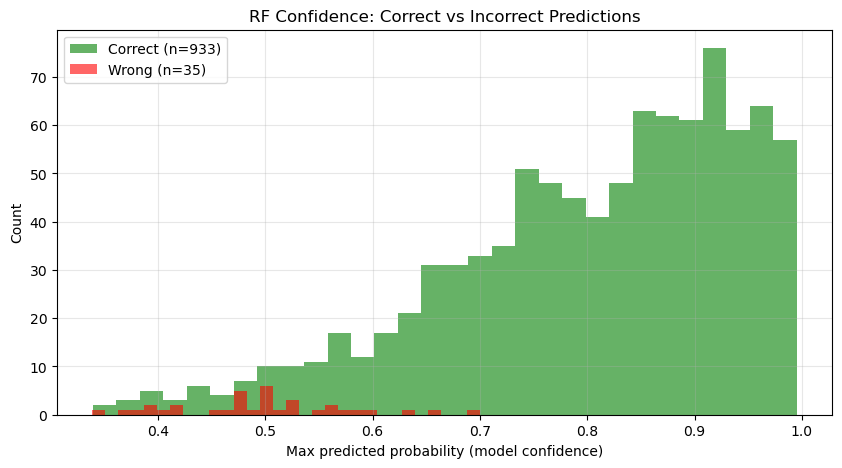


Mean confidence when correct:  0.802
Mean confidence when wrong:    0.497
Wrong predictions with >90% confidence: 0


In [11]:
test_probs = rf_test_results['probabilities']
test_preds = rf_test_results['predictions']
max_confidences = test_probs.max(axis=1)
correct = (test_preds == test_labels)

plt.figure(figsize=(10, 5))
plt.hist(max_confidences[correct], bins=30, alpha=0.6, label=f'Correct (n={correct.sum()})', color='green')
plt.hist(max_confidences[~correct], bins=30, alpha=0.6, label=f'Wrong (n={(~correct).sum()})', color='red')
plt.xlabel('Max predicted probability (model confidence)')
plt.ylabel('Count')
plt.title('RF Confidence: Correct vs Incorrect Predictions')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(RESULTS_DIR, 'rf_confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean confidence when correct:  {max_confidences[correct].mean():.3f}")
print(f"Mean confidence when wrong:    {max_confidences[~correct].mean():.3f}")
print(f"Wrong predictions with >90% confidence: {((~correct) & (max_confidences > 0.9)).sum()}")

In [12]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_preds)

print("Error breakdown (rows = actual, columns = predicted):\n")
for i, actual_cls in enumerate(CLASSES):
    for j, pred_cls in enumerate(CLASSES):
        if i != j and cm[i, j] > 0:
            print(f"  {actual_cls:7s} misclassified as {pred_cls:7s}: {cm[i, j]} cases ({cm[i, j]/cm[i].sum()*100:.1f}%)")

Error breakdown (rows = actual, columns = predicted):

  DME     misclassified as CNV    : 17 cases (7.0%)
  DME     misclassified as NORMAL : 11 cases (4.5%)
  DRUSEN  misclassified as CNV    : 7 cases (2.9%)


Confidence calibration: Random Forest demonstrates strong prediction calibration: mean confidence on correct predictions is 0.802, compared to just 0.497 on incorrect predictions. The model is effectively more certain when it is right, and less certain when it is wrong. Critically, none of the 35 misclassified test samples were predicted with confidence above 90% — the model never combines high confidence with a wrong answer. This property is particularly valuable in clinical settings, where a confidence-thresholding policy (e.g., flagging any prediction below 0.7 for manual review) could effectively eliminate high-confidence errors at the cost of deferring ~5–10% of cases to a specialist.

Error breakdown: The 35 misclassifications are concentrated in two failure modes:

DME → CNV (17 cases, 7.0% of DME samples) and DME → NORMAL (11 cases, 4.5%): DME is the hardest class for Random Forest, accounting for 80% of all errors. Mild DME cases can visually resemble normal scans (when fluid accumulation is limited), while more severe DME shares intraretinal fluid features with CNV.

DRUSEN → CNV (7 cases, 2.9%): A smaller but consistent pattern where DRUSEN (sub-retinal deposits) gets confused with CNV (choroidal neovascularization). Both conditions can involve sub-retinal abnormalities in early stages.

The persistent "X → CNV" confusion direction is expected — CNV is the majority class in training (44.6%), so boundary cases tend to drift toward its decision region despite class weighting.